## Olist E-Commerce Business Analysis
Author: Lalitha Anusha Nimmagadda  
Tools: SQL, Python (Pandas, Matplotlib), SQLite

## Project Overview

This project analyzes the Olist Brazilian e-commerce dataset using SQL and Python to evaluate revenue performance, customer retention, geographic concentration, and operational performance.

The goal is to identify key business drivers and derive strategic insights from transactional data.

### Key Questions Answered

1. What factors drive revenue growth over time?
2. Which regions contribute the most to total revenue?
3. How valuable are repeat customers compared to one-time buyers?
4. How does delivery performance impact customer satisfaction?

In [1]:
# import libraries

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
# import libraries
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files[:50]:
        print("  -", f)

In [3]:
# import libraries
import pandas as pd

# set dataset path
path = "../data/raw/"

# Load CSVs into Pandas DataFrames
customers = pd.read_csv(path + "olist_customers_dataset.csv")
orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
from pathlib import Path

project_root = Path.cwd().parent

# Figures folder
figures_path = project_root / "outputs" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

# Tables folder
tables_path = project_root / "outputs" / "tables"
tables_path.mkdir(parents=True, exist_ok=True)

In [5]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}

for name, df in tables.items():
    print(f"{name:12s} | rows={df.shape[0]:7d} | cols={df.shape[1]:2d}")

print("\nSample rows from orders:")
display(orders.head(3))

customers    | rows=  99441 | cols= 5
orders       | rows=  99441 | cols= 8
order_items  | rows= 112650 | cols= 7
payments     | rows= 103886 | cols= 5
reviews      | rows=  99224 | cols= 7
products     | rows=  32951 | cols= 9
sellers      | rows=   3095 | cols= 4

Sample rows from orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [6]:
import sqlite3

# Creating SQLite DB & load tables 
conn = sqlite3.connect("olist.db")

# Load dataframes into SQL tables
customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
sellers.to_sql("sellers", conn, if_exists="replace", index=False)

print("All tables loaded into SQL successfully!")

All tables loaded into SQL successfully!


In [7]:
# Confirm SQL tables exist 
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,customers
1,orders
2,order_items
3,payments
4,reviews
5,products
6,sellers


### Key Table Relationships (Data Model)

- `customers.customer_id` → `orders.customer_id`
- `orders.order_id` → `order_items.order_id`
- `orders.order_id` → `reviews.order_id`
- `order_items.product_id` → `products.product_id`
- `order_items.seller_id` → `sellers.seller_id`

### Analysis Scope & Assumptions

- Only orders with `order_status = 'delivered'` are included in revenue and customer metrics.
- Cancelled, unavailable, and non-fulfilled orders are excluded.
- This ensures financial KPIs reflect completed transactions only.

In [8]:
# KPI: Order Status Distribution
# Purpose: Understanding the distribution of order statuses before applying delivery filter.
# This helps validate data completeness and determine the share of delivered vs cancelled orders.
q = """
SELECT
  o.order_status,
  COUNT(*) AS orders_count
FROM orders o
GROUP BY o.order_status
ORDER BY orders_count DESC;
"""

status_counts = pd.read_sql_query(q, conn)

status_counts.to_csv("../outputs/tables/order_status_counts.csv", index=False)
status_counts

,order_status,orders_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### Insight
The majority of orders are delivered, confirming that filtering to delivered orders preserves most transaction volume while excluding cancelled and unavailable orders.

### 1. Revenue Analysis Total Revenue (GMV) and Average Order Value (AOV)

In [9]:
# KPI: Total GMV and AOV
# Purpose: Calculate total revenue generated from completed (delivered) orders and 
# determine the average revenue per order
# Business Relevance: Establishing baseline for financial performance which helps assess 
# whether revenue growth is driven by transaction volume or pricing power

q = """
-- Sum product price and freight for delivered orders
SELECT
  -- Gross Merchandise Value(GMV) 
  ROUND(SUM(oi.price + oi.freight_value), 2) AS total_gmv,
  COUNT(DISTINCT o.order_id) AS unique_delivered_orders,
  ROUND(SUM(oi.price + oi.freight_value) * 1.0 / COUNT(DISTINCT o.order_id), 2) AS aov
FROM orders o
JOIN order_items oi
  ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered';
"""

kpi_revenue = pd.read_sql_query(q, conn)
kpi_revenue

,total_gmv,unique_delivered_orders,aov
0,15419773.75,96478,159.83


### Monthly Revenue Trend

In [10]:
# KPI: Monthly Revenue Trend
# Purpose: Aggregate delivered order revenue by year-month to analyze revenue growth 
# patterns over time.
# Business Relevance: Identifies seasonal spikes (e.g., promotional events), and revenue stabilization periods.

q = """
SELECT
  -- strftime (string format time, SQLite date formatting function)
  -- strftime('%Y-%m', timestamp) extracts Year-Month from a datetime
  -- We use this to group revenue by month instead of by exact timestamp
  
strftime('%Y-%m', o.order_purchase_timestamp) AS year_month,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS monthly_revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY year_month
ORDER BY year_month;
"""

monthly_revenue = pd.read_sql_query(q, conn)


monthly_revenue.to_csv("../outputs/tables/monthly_revenue.csv", index=False)
monthly_revenue.head()

,year_month,monthly_revenue
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32


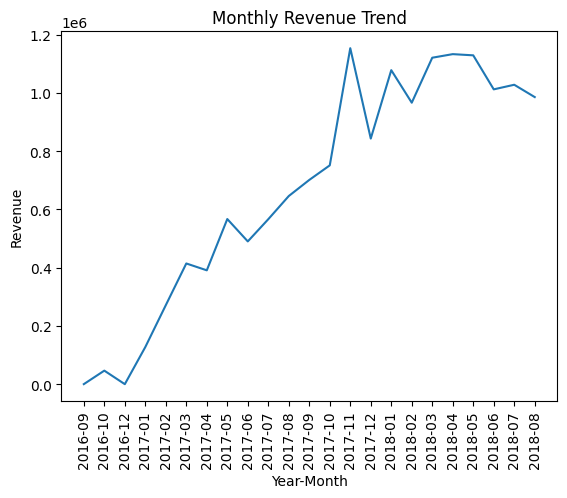

In [11]:
# Plot: Monthly Revenue Trend
# Purpose: Visualize how delivered revenue changes over time.
# Business Relevance: Helps identify growth trends and seasonal fluctuations.

import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_revenue["year_month"], monthly_revenue["monthly_revenue"])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.savefig(figures_path / "monthly_revenue_trend.png", bbox_inches='tight')
plt.show()

### Was revenue growth driven by: More orders? OR Higher AOV?

In [12]:
# KPI: Monthly Orders and AOV
# Purpose: Compare order volume and average order value over time to determine primary 
# revenue growth driver.
# Business Relevance: Distinguishes whether revenue growth is driven by customer 
# acquisition (volume) or higher customer spending (pricing).

q = """
-- KPI 3: Monthly Orders and AOV

SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS year_month,
    
    COUNT(DISTINCT o.order_id) AS monthly_orders,
    
    ROUND(SUM(oi.price + oi.freight_value), 2) AS monthly_revenue,
    
    ROUND(
        SUM(oi.price + oi.freight_value) * 1.0 
        / COUNT(DISTINCT o.order_id), 2) AS monthly_aov

FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id

WHERE o.order_status = 'delivered'

GROUP BY year_month
ORDER BY year_month;
"""

monthly_kpis = pd.read_sql_query(q, conn)

monthly_kpis.to_csv("../outputs/tables/monthly_kpis.csv", index=False)
monthly_kpis.head()

,year_month,monthly_orders,monthly_revenue,monthly_aov
0,2016-09,1,143.46,143.46
1,2016-10,265,46490.66,175.44
2,2016-12,1,19.62,19.62
3,2017-01,750,127482.37,169.98
4,2017-02,1653,271239.32,164.09


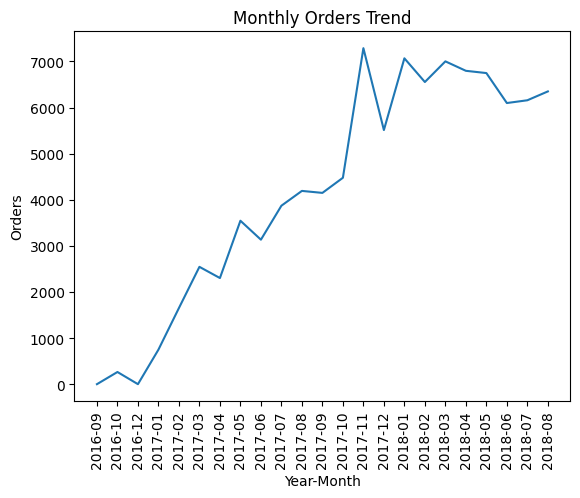

In [13]:
# Plot: Monthly Order Volume Trend
# Purpose: Visualization changes in number of delivered orders over time.
# Business Relevance: Helps determine whether revenue growth is driven by 
# increasing customer transactions (volume expansion).
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_kpis["year_month"], monthly_kpis["monthly_orders"])
plt.xticks(rotation=90)
plt.title("Monthly Orders Trend")
plt.xlabel("Year-Month")
plt.ylabel("Orders")

plt.savefig(figures_path / "monthly_orders_trend.png", bbox_inches='tight')
plt.show()

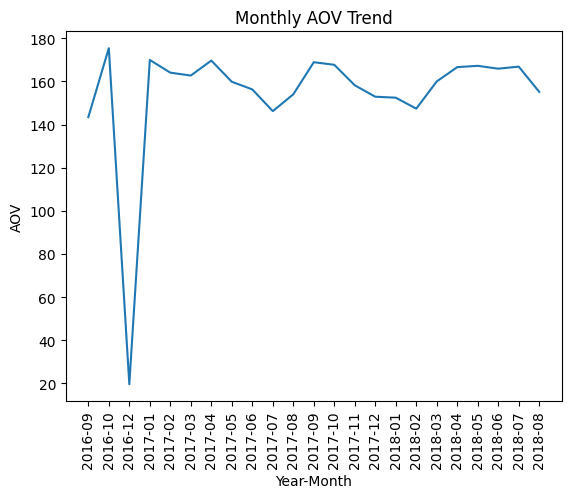

In [14]:
# Plot: Monthly Average Order Value (AOV) Trend
# Purpose: Track changes in average revenue per order over time.
# Business Relevance: Indicates whether revenue growth is influenced by 
# pricing/spending behavior rather than transaction volume.

plt.figure()
plt.plot(monthly_kpis["year_month"], monthly_kpis["monthly_aov"])
plt.xticks(rotation=90)
plt.title("Monthly AOV Trend")
plt.xlabel("Year-Month")
plt.ylabel("AOV")

plt.savefig(figures_path / "monthly_aov_trend.png", bbox_inches='tight')
plt.show()

### Insights

Total GMV is approximately 15.4M across ~96K delivered orders. Revenue growth accelerated significantly during 2017.

Average Order Value (AOV) remained relatively stable (~160). Revenue growth was primarily driven by increasing order volume rather than higher customer spending.

### Business Interpretation

Revenue expansion was largely acquisition-driven, indicating that platform growth depended on increasing transaction volume rather than pricing power. Sustaining long-term growth will require improving customer retention and lifetime value rather than relying solely on new customer acquisition.

### 2. Which states generate the most revenue?

In [15]:
# KPI: Revenue by Customer State
# Purpose: Calculate total revenue and order volume by geographic region.
# Business Relevance: Identifies revenue concentration risk and highlights high-performing 
# markets for expansion strategy.

q = """
SELECT
    c.customer_state,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_revenue DESC;
"""

state_revenue = pd.read_sql_query(q, conn)

state_revenue.to_csv("../outputs/tables/state_revenue.csv", index=False)
state_revenue.head()

,customer_state,total_revenue,total_orders
0,SP,5769703.15,40501
1,RJ,2055401.57,12350
2,MG,1818891.67,11354
3,RS,861472.79,5345
4,PR,781708.80,4923


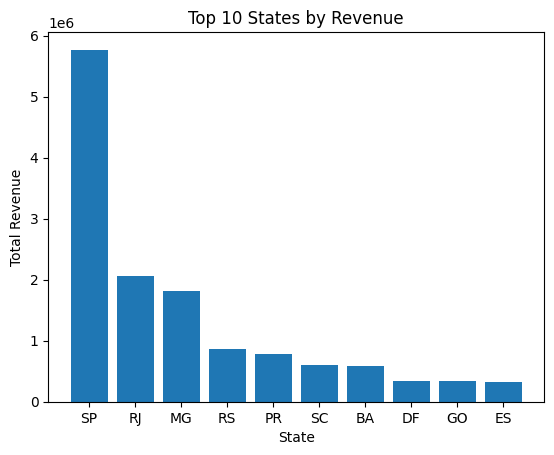

In [16]:
# Plot: Top 10 States by Revenue
# Purpose: Visualize revenue contribution by customer state to identify
# geographic concentration.
# Business Relevance: Highlights revenue dependency on major markets
# (e.g., São Paulo) and potential expansion opportunities in underpenetrated regions.

top_states = state_revenue.sort_values("total_revenue", ascending=False).head(10)

plt.figure()
plt.bar(top_states["customer_state"], top_states["total_revenue"])
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Total Revenue")

plt.savefig(figures_path / "top_10_states_by_revenue.png", bbox_inches='tight')
plt.show()

### Is SP generating high revenue because: Customers spend more? OR There are just more orders?

In [17]:
# KPI: Average Order Value by State
# Purpose: Measure differences in spending behavior across regions.
# Business Relevance: Determines whether high-revenue states are driven by higher 
# transaction volume or higher customer spending per order.

q = """

SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
    ROUND(
        SUM(oi.price + oi.freight_value) * 1.0
        / COUNT(DISTINCT o.order_id), 2) AS state_aov
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY state_aov DESC;
"""

state_aov = pd.read_sql_query(q, conn)

state_aov.to_csv("../outputs/tables/state_aov.csv", index=False)
state_aov.head()

,customer_state,total_orders,total_revenue,state_aov
0,PB,517,137838.55,266.61
1,AC,80,19575.33,244.69
2,AP,67,16141.81,240.92
3,AL,397,94172.49,237.21
4,RO,243,56966.00,234.43


### Is higher AOV in small states driven by: Higher product prices? OR Higher freight (shipping) costs?

In [18]:
# KPI: Product vs Freight Contribution to AOV by State
# Purpose: Break down Average Order Value (AOV) into product price and freight
# components at the state level.
# Business Relevance: Determines whether high AOV in certain regions is driven
# by higher customer spending behavior or inflated logistics costs, which has
# implications for pricing strategy and supply chain optimization.

q = """
-- Decompose AOV into product and freight components by customer state
SELECT
    c.customer_state,
    
    COUNT(DISTINCT o.order_id) AS total_orders,
    
    -- Average product value per order
    ROUND(
        SUM(oi.price) * 1.0 
        / COUNT(DISTINCT o.order_id), 2) AS avg_product_value_per_order,
    
    -- Average freight cost per order
    ROUND(
        SUM(oi.freight_value) * 1.0 
        / COUNT(DISTINCT o.order_id), 2) AS avg_freight_per_order,
    
    -- Total AOV (product + freight)
    ROUND(
        SUM(oi.price + oi.freight_value) * 1.0 
        / COUNT(DISTINCT o.order_id), 2) AS state_aov

FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN customers c
    ON o.customer_id = c.customer_id

WHERE o.order_status = 'delivered'

GROUP BY c.customer_state
ORDER BY state_aov DESC;
"""

state_cost_breakdown = pd.read_sql_query(q, conn)

state_cost_breakdown.to_csv("../outputs/tables/state_cost_breakdown.csv", index=False)
state_cost_breakdown.head()

,customer_state,total_orders,avg_product_value_per_order,avg_freight_per_order,state_aov
0,PB,517,217.77,48.84,266.61
1,AC,80,199.14,45.55,244.69
2,AP,67,199.62,41.30,240.92
3,AL,397,198.63,38.58,237.21
4,RO,243,187.99,46.43,234.43


In [19]:
# Focus Analysis: Benchmark High-AOV States Against São Paulo (SP)
# Purpose: Compare major revenue-driving state (SP) with high-AOV but low-volume states.
# Business Relevance: Helps determine whether revenue dominance is volume-driven
# (SP) versus price/logistics-driven (remote states).

state_cost_breakdown.loc[
    state_cost_breakdown["customer_state"] == "SP"
]

,customer_state,total_orders,avg_product_value_per_order,avg_freight_per_order,state_aov
26,SP,40501,125.12,17.33,142.46


### Insights

São Paulo (SP) contributes the highest share of revenue and order volume. Revenue is heavily concentrated in major urban states.

Smaller states exhibit higher AOV, partially driven by higher freight costs. Elevated AOV in remote regions is influenced by logistics rather than pure spending behavior.

### Business Interpretation

The platform shows strong geographic concentration risk, particularly in São Paulo. While smaller states show higher AOV, this is partly inflated by freight costs. Expansion strategies should focus on diversifying revenue sources while optimizing logistics in remote regions to improve competitiveness.

### 3. Customer Retention Analysis

In [20]:
# KPI: Customer Repeat Rate
# Purpose: Calculate the percentage of unique customers who placed more than one delivered order.
# Business Relevance: Measures true customer retention and determines whether platform growth 
# is driven primarily by acquisition or repeat purchasing.

q = """

SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY COUNT(DISTINCT o.order_id) desc;
"""

customer_orders = pd.read_sql_query(q, conn)

customer_orders.to_csv("../outputs/tables/customer_orders.csv", index=False)
customer_orders.head()

,customer_unique_id,total_orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,15
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7


In [21]:
# calculate retention metrics from order frequency distribution
# Helps Identify how many customers return for additional purchases.

total_customers = customer_orders.shape[0]

# Customers with 2+ delivered orders are classified as repeat customers
repeat_customers = customer_orders.loc[
    customer_orders["total_orders"] > 1
].shape[0]

# Retention rate = repeat customers / total unique customers
retention_rate = repeat_customers / total_customers

print("Total Unique Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Retention Rate:", round(retention_rate * 100, 2), "%")


import pandas as pd

retention_table = pd.DataFrame({
    "metric": ["Total Unique Customers", "Repeat Customers", "Retention Rate (%)"],
    "value": [total_customers, repeat_customers, round(retention_rate * 100, 2)]
})

retention_table.to_csv("../outputs/tables/customer_retention_summary.csv", index=False)

Total Unique Customers: 93358
Repeat Customers: 2801
Retention Rate: 3.0 %


### Are repeat customers more valuable than one-time customers?

In [22]:
# KPI: Revenue per Customer Segment (Repeat vs One-Time)
# Purpose: Compare average revenue and order frequency between repeat and single-purchase customers.
# Business Relevance: Quantifies the financial impact of retention and evaluates the potential ROI 
# of loyalty initiatives.

q = """

SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id;
"""

customer_value = pd.read_sql_query(q, conn)


customer_value.to_csv("../outputs/tables/customer_value.csv", index=False)
customer_value.head()

,customer_unique_id,total_orders,total_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


### Repeat vs One-Time

In [23]:
# KPI: Revenue Comparison by Customer Segment
# Purpose: Segment customers into Repeat (2+ orders) and One-Time (1 order) groups
# and compare their revenue contribution and purchasing behavior.
# Business Relevance: Quantifies the financial value of retention and helps assess
# whether increasing repeat rate would meaningfully impact total revenue.

# Create customer segment based on purchase frequency
customer_value["segment"] = customer_value["total_orders"].apply(
    lambda x: "Repeat" if x > 1 else "One-Time"
)

# Group summary
segment_summary = customer_value.groupby("segment").agg(
    customers=("customer_unique_id", "count"),
    avg_orders=("total_orders", "mean"),
    avg_revenue=("total_revenue", "mean")
).reset_index()


segment_summary.to_csv("../outputs/tables/segment_summary.csv", index=False)
segment_summary

,segment,customers,avg_orders,avg_revenue
0,One-Time,90557,1.000000,160.733972
1,Repeat,2801,2.113888,308.528190


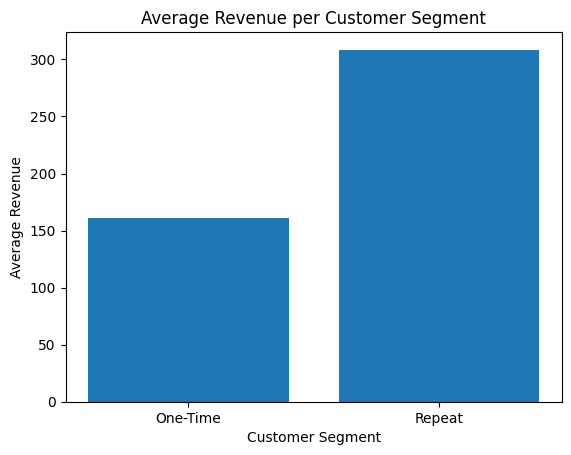

In [24]:
# Plot: Average Revenue per Customer Segment
# Purpose: Compare revenue contribution between Repeat and One-Time customers.
# Business Relevance: Demonstrates the financial value of retention and
# supports investment decisions in loyalty and remarketing strategies.

plt.figure()
plt.bar(segment_summary["segment"], segment_summary["avg_revenue"])
plt.title("Average Revenue per Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue")

plt.savefig(figures_path / "average_revenue_per_customer_segment.png", bbox_inches='tight')
plt.show()

### Are repeat customers coming back quickly, or after long gaps?

In [25]:
# KPI: Repeat Purchase Cycle (First → Second Purchase)
# Purpose: Extract purchase timestamps for delivered orders so we can calculate how long it takes 
# repeat customers to return for a second purchase.
# Business Relevance: Helps quantify customer engagement frequency and guides remarketing timing 
# (e.g., when to send follow-up offers after the first purchase).

q = """
-- Pull delivered purchase timestamps per unique customer (chronological order)
SELECT
    c.customer_unique_id,
    o.order_purchase_timestamp
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
ORDER BY c.customer_unique_id, o.order_purchase_timestamp;
"""

customer_dates = pd.read_sql_query(q, conn)
customer_dates.head()

,customer_unique_id,order_purchase_timestamp
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [26]:
# Preparing timestamps for date arithmetic
# Help Converting to datetime enables accurate time-difference calculations.
customer_dates["order_purchase_timestamp"] = pd.to_datetime(customer_dates["order_purchase_timestamp"])

# Step: Focus only on repeat customers
# Why: The repeat purchase cycle is defined only for customers with 2+ delivered orders.
repeat_ids = customer_value.loc[customer_value["total_orders"] > 1, "customer_unique_id"]

repeat_data = customer_dates.loc[
    customer_dates["customer_unique_id"].isin(repeat_ids)
].copy()

# Step: Rank each customer's orders chronologically (1st order, 2nd order, ...)
# Why: We specifically need the first and second purchase timestamps.
repeat_data["order_rank"] = repeat_data.groupby("customer_unique_id").cumcount() + 1

# Step: Keep only first and second orders to compute first→second gap
first_second = repeat_data.loc[repeat_data["order_rank"] <= 2].copy()

# Step: Pivot so each customer becomes one row with first_order and second_order columns
# Why: Makes it easy to subtract dates and compute days_between_orders.
pivot = first_second.pivot(
    index="customer_unique_id",
    columns="order_rank",
    values="order_purchase_timestamp"
).reset_index()

pivot.columns = ["customer_unique_id", "first_order", "second_order"]

In [27]:
# KPI Output: Days between first and second order
# Why: Quantifies the repeat purchase cycle length.
pivot["days_between_orders"] = (pivot["second_order"] - pivot["first_order"]).dt.days

pivot.to_csv("../outputs/tables/repeat_purchase_cycle.csv", index=False)
pivot.head()

,customer_unique_id,first_order,second_order,days_between_orders
0,004288347e5e88a27ded2bb23747066c,2017-07-27 14:13:03,2018-01-14 07:36:54,170
1,00a39521eb40f7012db50455bf083460,2018-05-23 20:14:21,2018-06-03 10:12:57,10
2,00cc12a6d8b578b8ebd21ea4e2ae8b27,2017-03-21 19:25:22,2017-03-21 19:25:23,0
3,011575986092c30523ecb71ff10cb473,2018-02-17 15:54:49,2018-04-18 21:58:08,60
4,011b4adcd54683b480c4d841250a987f,2017-08-22 12:51:29,2018-02-15 11:40:57,176


### Insights

Only ~3% of customers made repeat purchases. Repeat customers generate nearly 2x higher average revenue ~309 compared to one-time buyers ~161.

The average repeat purchase cycle is approximately 81 days, indicating moderate engagement frequency.

### Business Interpretation

Although retention rate is low, repeat customers are significantly more valuable. Increasing retention even marginally could meaningfully increase overall revenue without proportional acquisition costs. Implementing loyalty programs, remarketing campaigns, and personalized offers may improve long-term profitability.

### 4. Do delivery delays affect customer review scores?

In [28]:
# KPI: Delivery Delay Impact on Customer Satisfaction
# Purpose: Measure difference in review scores between late and on-time deliveries.
# Business Relevance: Evaluates operational performance as a driver of customer satisfaction and 
# brand perception.

q = """

SELECT
    o.order_id,
    c.customer_unique_id,
    r.review_score,
    
--JULIANDAY(date) converts a date into a numeric day count
--Positive → delivered late
--Negative → delivered early
--Zero → on time

    JULIANDAY(o.order_delivered_customer_date) 
    - JULIANDAY(o.order_estimated_delivery_date)
    AS delivery_delay_days

FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN reviews r
    ON o.order_id = r.order_id

WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
AND o.order_estimated_delivery_date IS NOT NULL;
"""

delivery_reviews = pd.read_sql_query(q, conn)

delivery_reviews.to_csv("../outputs/tables/delivery_reviews.csv", index=False)
delivery_reviews.head()

,order_id,customer_unique_id,review_score,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,4,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,4,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,5,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,5,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,5,-9.238171


In [29]:
# Categorize late vs on time delivery with review score
delivery_reviews["delivery_status"] = delivery_reviews["delivery_delay_days"].apply(
    lambda x: "Late" if x > 0 else "On-Time/Early"
)

review_summary = delivery_reviews.groupby("delivery_status")["review_score"].mean().reset_index()

review_summary.to_csv("../outputs/tables/review_summary_cycle.csv", index=False)
review_summary

,delivery_status,review_score
0,Late,2.566494
1,On-Time/Early,4.293718


### Are customers who experienced a late delivery less likely to repeat?

In [30]:
# KPI: Customers Experiencing Late Delivery
# Purpose: Identify customers who experienced at least one delayed delivery 
# (actual delivery date later than estimated date).
# Business Relevance: Enables segmentation of customers based on operational experience to 
# evaluate whether delivery performance influences retention behavior.

q = """

SELECT DISTINCT
    c.customer_unique_id
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
AND JULIANDAY(o.order_delivered_customer_date) 
    - JULIANDAY(o.order_estimated_delivery_date) > 0;
"""

late_customers = pd.read_sql_query(q, conn)
late_customers.head()

,customer_unique_id
0,d699688533772c15a061e8ce81cb56df
1,a25d5f94840d3c6a1a49f271ed83f4ec
2,92fd8aa5948e20c43a014c44c025c5e1
3,3e4fd73f1e86b135b9b121d6abbe9597
4,ddf60e20e6e262e2136801ce5cd628b0


In [31]:
# KPI: Delivery Delay vs Customer Retention
# Purpose: Compare repeat purchase rates between customers who experienced late deliveries and 
# those who did not.
# Business Relevance: Determines whether operational performance impacts long-term customer loyalty 
# and repeat purchasing behavior.

customer_value["had_late_delivery"] = customer_value["customer_unique_id"].isin(
    late_customers["customer_unique_id"]
)

# Group by late vs no late
retention_comparison = customer_value.groupby("had_late_delivery").agg(
    customers=("customer_unique_id", "count"),
    repeat_rate=("total_orders", lambda x: (x > 1).mean())
).reset_index()


retention_comparison.to_csv("../outputs/tables/late_delivery_retention_comparison.csv", index=False)
retention_comparison

,had_late_delivery,customers,repeat_rate
0,False,85587,0.028544
1,True,7771,0.046069


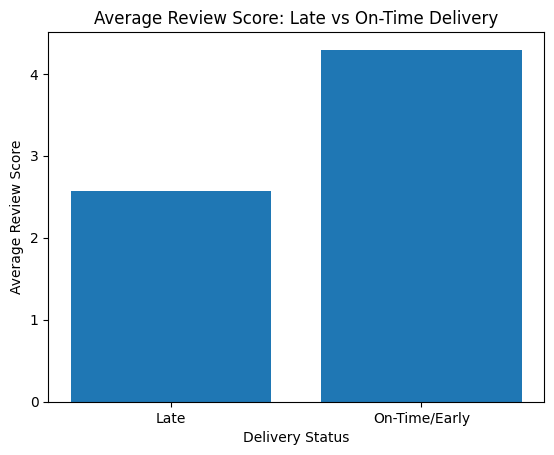

In [32]:
# Plot: Impact of Delivery Delay on Customer Satisfaction
# Purpose: Compare average review scores for late vs on-time deliveries.
# Business Relevance: Evaluates how operational performance affects
# customer satisfaction and brand perception.

plt.figure()
plt.bar(review_summary["delivery_status"], review_summary["review_score"])
plt.title("Average Review Score: Late vs On-Time Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.savefig(figures_path / "average_review_score_late_vs_on-time_delivery.png", bbox_inches='tight')
plt.show()

### Insights

Late deliveries receive significantly lower review scores ~2.6 compared to on-time deliveries ~4.3. Operational performance strongly impacts customer satisfaction.

However, repeat rates do not significantly decrease among customers who experienced late deliveries.

### Business Interpretation

Delivery reliability is a critical driver of customer satisfaction and brand perception. While delays negatively impact reviews, repeat purchasing appears influenced more by marketplace need than satisfaction alone. Operational improvements can enhance customer experience, but retention strategies must also address engagement and value perception.

## Executive-Level Synthesis

Overall Key Findings

1. Growth was volume-driven, not price-driven. 
2. Revenue is geographically concentrated. 
3. Retention rate is low but financially impactful. 
4. Logistics performance significantly affects satisfaction. 
5. Repeat purchase behavior occurs on a ~3-month cycle. 
 
Strategic Direction

To drive sustainable growth, Olist should prioritize:
1. Retention strategy development.
2. Logistics optimization in remote regions.
3. Geographic revenue diversification.
4. Targeted remarketing aligned with the 81-day repeat cycle.

## Executive Summary

1. **Revenue & Growth**
   - Total GMV: ~15.4M across ~96K delivered orders.
   - Revenue growth during 2017 was primarily volume-driven, not AOV-driven.
   - Average Order Value (AOV) remained stable at ~160 per order.

2. **Geographic Concentration**
   - São Paulo (SP) accounts for the largest share of revenue and orders.
   - Smaller states show higher AOV, partially driven by elevated freight costs.
   - Revenue is highly concentrated in urban regions, creating geographic dependency risk.

3. **Customer Retention**
   - Only ~3% of customers made repeat purchases.
   - Repeat customers generate nearly **2× higher average revenue (~309)** compared to one-time buyers (~161).
   - Repeat purchase cycle averages **~81 days**.

4. **Operational Impact**
   - Late deliveries receive significantly lower review scores (**2.57**) compared to on-time deliveries (**4.29**).
   - While delivery delays strongly affect satisfaction, repeat rate is not significantly reduced, suggesting retention drivers may differ from satisfaction drivers.

## Strategic Recommendations

1️. Invest in Retention Strategy
Repeat customers are significantly more valuable. Introducing loyalty programs, remarketing campaigns, and personalized offers could meaningfully increase lifetime value.

2️. Optimize Freight in Remote Regions
High AOV in smaller states is partly driven by freight costs. Logistics optimization may improve competitiveness and customer perception.

3️. Improve Delivery Reliability
Delivery delays significantly reduce review scores. Strengthening last-mile logistics can enhance customer experience and brand perception.

4️. Diversify Geographic Revenue Base
Heavy reliance on São Paulo creates concentration risk. Expansion strategies in underpenetrated states may improve revenue stability.